# Notebook 05: Multivariate Analysis

## Objective
Understand how **combinations** of workplace factors interact to drive attrition — patterns invisible in bivariate analysis.

## Analyses
1. Salary × Experience × Department → Attrition
2. Weekly Hours × OverTime × Work-Life Balance → Engagement & Attrition
3. Promotion Gap × Tenure × Career Growth → Attrition
4. Manager Support × Workload × Job Satisfaction → Attrition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

TEAL='#1B4F72'; BLUE='#2E86C1'; RED='#E74C3C'; GREEN='#27AE60'; AMBER='#F39C12'

df = pd.read_csv('../data/processed/employee_attrition_augmented.csv')
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Attrition rate: {df["Attrition_Binary"].mean()*100:.1f}%')

Dataset: 1,470 rows x 44 columns
Attrition rate: 16.1%


---
## Analysis 1: Salary × Experience × Department → Attrition

**Question:** Does the income gap concentrate in specific salary-experience combinations, or is it uniform across the organisation?

**H₀:** Attrition rate is uniform across Salary Band × Experience Band combinations  
**H₁:** Certain low-salary early-career cells carry disproportionately high attrition

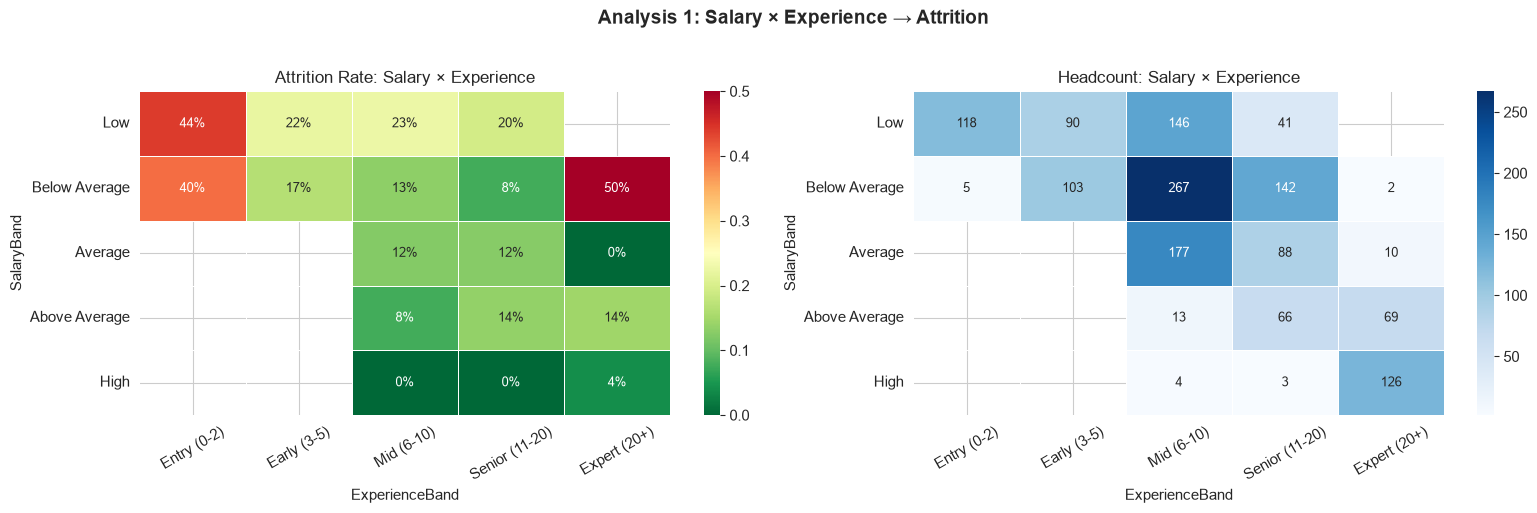

In [2]:
salary_order = ['Low','Below Average','Average','Above Average','High']
exp_order = ['Entry (0-2)','Early (3-5)','Mid (6-10)','Senior (11-20)','Expert (20+)']

pivot = (df.groupby(['SalaryBand','ExperienceBand'])['Attrition_Binary']
           .mean().unstack()
           .reindex(index=salary_order, columns=exp_order))

pivot_n = (df.groupby(['SalaryBand','ExperienceBand'])['Attrition_Binary']
             .count().unstack()
             .reindex(index=salary_order, columns=exp_order))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', ax=axes[0],
            linewidths=0.5, vmin=0, vmax=0.5, annot_kws={'size':9})
axes[0].set_title('Attrition Rate: Salary × Experience', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(pivot_n, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
            linewidths=0.5, annot_kws={'size':9})
axes[1].set_title('Headcount: Salary × Experience', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Analysis 1: Salary × Experience → Attrition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

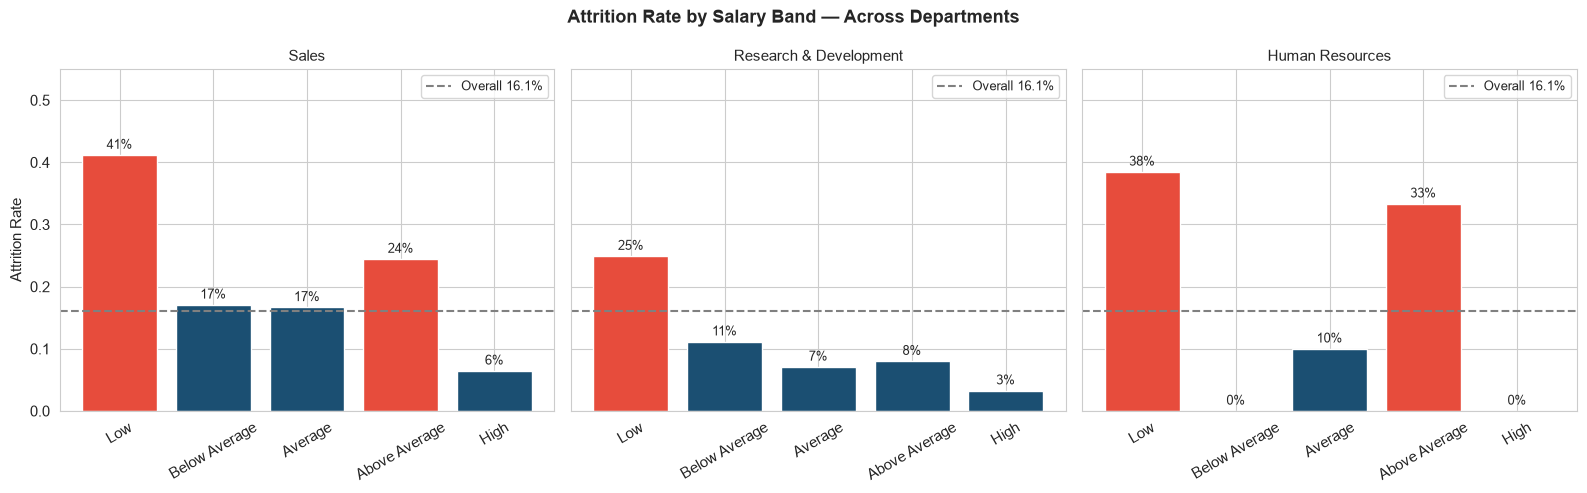

In [3]:
# Department-level facets
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)
overall_rate = df['Attrition_Binary'].mean()

for ax, dept in zip(axes, df['Department'].unique()):
    dept_df = df[df['Department']==dept]
    rates = dept_df.groupby('SalaryBand')['Attrition_Binary'].mean().reindex(salary_order)
    colors = [RED if (v>0.20) else TEAL for v in rates.fillna(0)]
    bars = ax.bar(salary_order, rates, color=colors, edgecolor='white')
    ax.axhline(overall_rate, color='gray', linestyle='--', lw=1.5, label=f'Overall {overall_rate*100:.1f}%')
    for bar, rate in zip(bars, rates):
        if not pd.isna(rate):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{rate*100:.0f}%', ha='center', fontsize=9)
    ax.set_title(dept, fontsize=11); ax.set_ylim(0,0.55)
    ax.tick_params(axis='x', rotation=30)
    if ax==axes[0]: ax.set_ylabel('Attrition Rate')
    ax.legend(fontsize=9)

plt.suptitle('Attrition Rate by Salary Band — Across Departments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Attrition concentrates in the Low/Below Average salary band at Entry and Early career stages across **all three departments** — confirming this is an organisation-wide structural issue rather than a departmental one. Sales shows elevated attrition in mid-salary bands too, pointing to non-compensation drivers (overtime, travel).

---
## Analysis 2: Weekly Hours × OverTime × Work-Life Balance → Attrition

**Question:** Does overtime harm retention primarily through hours, or through the *perceived* work-life balance damage it causes?

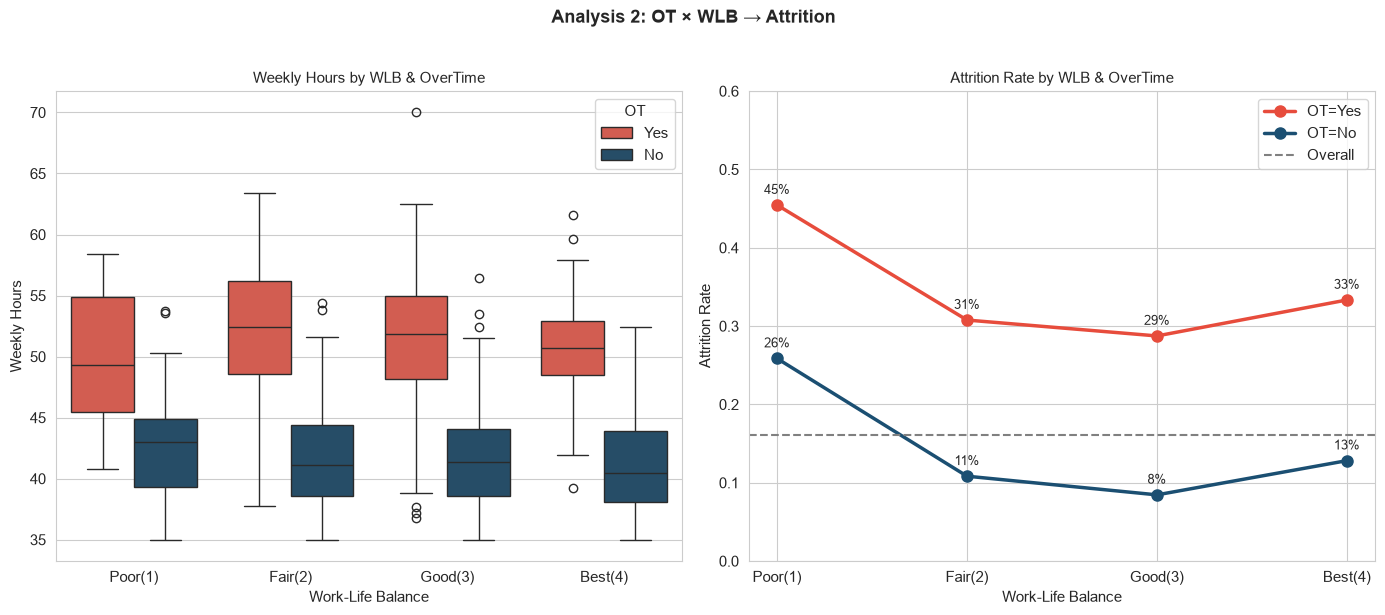

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
wlb_order = [1,2,3,4]
wlb_labels = ['Poor(1)','Fair(2)','Good(3)','Best(4)']

# Panel 1: Box plot of weekly hours by WLB and OT
df['WLB_Label'] = df['WorkLifeBalance'].map({1:'Poor(1)',2:'Fair(2)',3:'Good(3)',4:'Best(4)'})
sns.boxplot(data=df, x='WLB_Label', y='WeeklyHoursWorked', hue='OverTime',
            palette={'Yes':RED,'No':TEAL}, ax=axes[0],
            order=wlb_labels)
axes[0].set_title('Weekly Hours by WLB & OverTime', fontsize=11)
axes[0].set_xlabel('Work-Life Balance'); axes[0].set_ylabel('Weekly Hours')
axes[0].legend(title='OT')

# Panel 2: Attrition rate by WLB x OT
grp = df.groupby(['WLB_Label','OverTime'])['Attrition_Binary'].mean().reset_index()
for ot, color in [('Yes',RED),('No',TEAL)]:
    sub = grp[grp['OverTime']==ot].set_index('WLB_Label').reindex(wlb_labels)
    axes[1].plot(wlb_labels, sub['Attrition_Binary'], marker='o', color=color,
                 lw=2.5, markersize=8, label=f'OT={ot}')
    for i,v in enumerate(sub['Attrition_Binary']):
        if not pd.isna(v):
            axes[1].annotate(f'{v*100:.0f}%',(i,v),textcoords='offset points',
                              xytext=(0,8),ha='center',fontsize=9)
axes[1].axhline(overall_rate, color='gray', linestyle='--', lw=1.5, label='Overall')
axes[1].set_xlabel('Work-Life Balance'); axes[1].set_ylabel('Attrition Rate')
axes[1].set_title('Attrition Rate by WLB & OverTime', fontsize=11)
axes[1].legend(); axes[1].set_ylim(0,0.6)

plt.suptitle('Analysis 2: OT × WLB → Attrition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** **Overtime with good work-life balance (WLB=3-4) has much lower attrition** than overtime with poor WLB. The problem is not hours per se — it is employees who feel those hours are encroaching on their personal lives. Interventions targeting both overtime reduction AND flexibility/boundary-setting will outperform either alone.

---
## Analysis 3: Promotion Gap × Tenure × Career Growth → Attrition

**Question:** Is career stagnation worse for short-tenure employees (expectation mismatch) or long-tenure employees (career ceiling)?

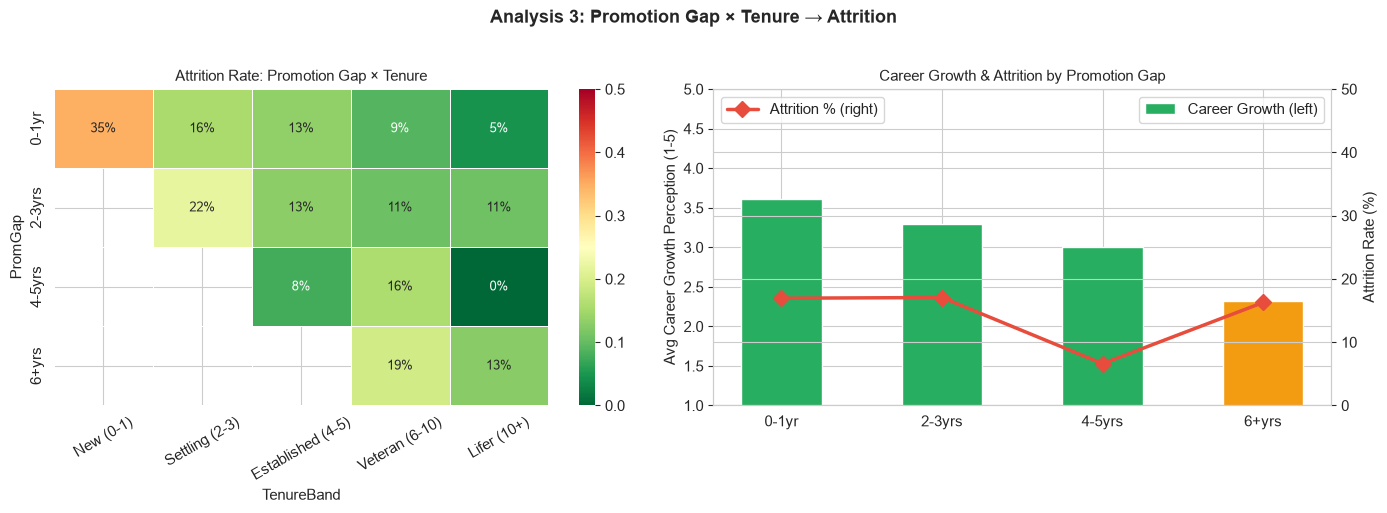

In [5]:
df['PromGap'] = pd.cut(df['YearsSinceLastPromotion'], bins=[-1,1,3,5,15],
                        labels=['0-1yr','2-3yrs','4-5yrs','6+yrs'])
tenure_order = ['New (0-1)','Settling (2-3)','Established (4-5)','Veteran (6-10)','Lifer (10+)']
promo_order  = ['0-1yr','2-3yrs','4-5yrs','6+yrs']

pivot_p = (df.groupby(['PromGap','TenureBand'])['Attrition_Binary']
             .mean().unstack().reindex(index=promo_order, columns=tenure_order))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.heatmap(pivot_p, annot=True, fmt='.0%', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5, vmin=0, vmax=0.5, annot_kws={'size':9})
axes[0].set_title('Attrition Rate: Promotion Gap × Tenure', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

cgp = df.groupby('PromGap')['CareerGrowthPerception'].mean().reindex(promo_order)
atr = df.groupby('PromGap')['Attrition_Binary'].mean().reindex(promo_order)

ax2 = axes[1]; ax2t = ax2.twinx()
bcols = [GREEN if v>=3 else AMBER if v>=2 else RED for v in cgp]
ax2.bar(promo_order, cgp, color=bcols, edgecolor='white', width=0.5, label='Career Growth (left)')
ax2t.plot(promo_order, atr*100, color=RED, marker='D', markersize=8, lw=2.5, label='Attrition % (right)')
ax2.set_ylabel('Avg Career Growth Perception (1-5)'); ax2.set_ylim(1,5)
ax2t.set_ylabel('Attrition Rate (%)'); ax2t.set_ylim(0,50)
ax2.set_title('Career Growth & Attrition by Promotion Gap', fontsize=11)
ax2t.legend(loc='upper left'); ax2.legend(loc='upper right')

plt.suptitle('Analysis 3: Promotion Gap × Tenure → Attrition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Stagnation (6+ years without promotion) hits hardest in early career (New/Settling bands) — employees with high expectations who have not seen progression. For longer-tenured employees the effect is real but smaller (higher switching costs, lower alternatives). Career growth perception deteriorates monotonically with promotion gap, confirming the perception variable tracks objective promotion data.

---
## Analysis 4: Manager Support × Workload × Satisfaction → Attrition

**Question:** Does strong manager support buffer the negative effects of high workload — an interaction effect?

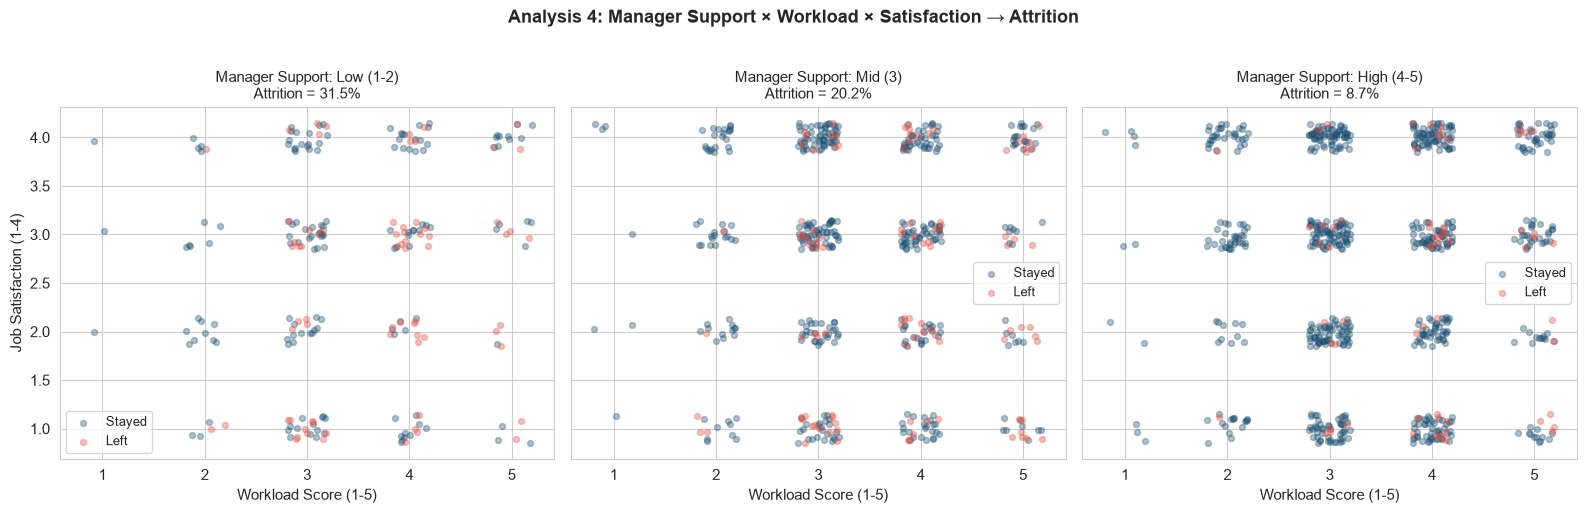

Attrition by Manager Support × Workload tier:
                        Attrition Rate    n
MgrTier    WLtier                          
High (4-5) High(4-5)             13.0%  353
           Low-Mid(1-3)           4.7%  386
Low (1-2)  High(4-5)             39.8%  103
           Low-Mid(1-3)          24.4%  119
Mid (3)    High(4-5)             26.1%  238
           Low-Mid(1-3)          15.1%  271


In [6]:
df['MgrTier'] = df['ManagerSupportScore'].apply(
    lambda x: 'Low (1-2)' if x<=2 else 'High (4-5)' if x>=4 else 'Mid (3)')
mgr_order = ['Low (1-2)','Mid (3)','High (4-5)']

fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True, sharex=True)
for ax, tier in zip(axes, mgr_order):
    sub = df[df['MgrTier']==tier]
    for attr, color, lbl in [('No',TEAL,'Stayed'),('Yes',RED,'Left')]:
        s = sub[sub['Attrition']==attr]
        jx = s['WorkloadScore'] + np.random.uniform(-0.2,0.2,len(s))
        jy = s['JobSatisfaction'] + np.random.uniform(-0.15,0.15,len(s))
        ax.scatter(jx, jy, alpha=0.35, s=18, color=color, label=lbl)
    rate = sub['Attrition_Binary'].mean()*100
    ax.set_title(f'Manager Support: {tier}\nAttrition = {rate:.1f}%', fontsize=11)
    ax.set_xlabel('Workload Score (1-5)')
    if ax==axes[0]: ax.set_ylabel('Job Satisfaction (1-4)')
    ax.legend(fontsize=9)

plt.suptitle('Analysis 4: Manager Support × Workload × Satisfaction → Attrition',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quantify the interaction
df['WLtier'] = df['WorkloadScore'].apply(lambda x: 'High(4-5)' if x>=4 else 'Low-Mid(1-3)')
grp = df.groupby(['MgrTier','WLtier'])['Attrition_Binary'].agg(['mean','count'])
grp.columns = ['Attrition Rate','n']
grp['Attrition Rate'] = grp['Attrition Rate'].map('{:.1%}'.format)
print('Attrition by Manager Support × Workload tier:')
print(grp.to_string())

**Interpretation:** Manager support acts as a **protective buffer**. High workload + low manager support produces the worst attrition; high workload + high manager support is substantially lower. Reducing workload alone without fixing manager quality captures less impact than addressing both.

---
## Summary: Multi-Factor Risk Multipliers

Baseline attrition: 16.1%
Scenario                                     Rate Multiplier
------------------------------------------------------------
Low Salary + Entry Career                  44.1%       2.73x
OverTime + Poor WLB (=1)                   45.5%       2.82x
OT + Poor WLB + Low Salary                 71.4%       4.43x
High Workload + Low Mgr Support            39.8%       2.47x


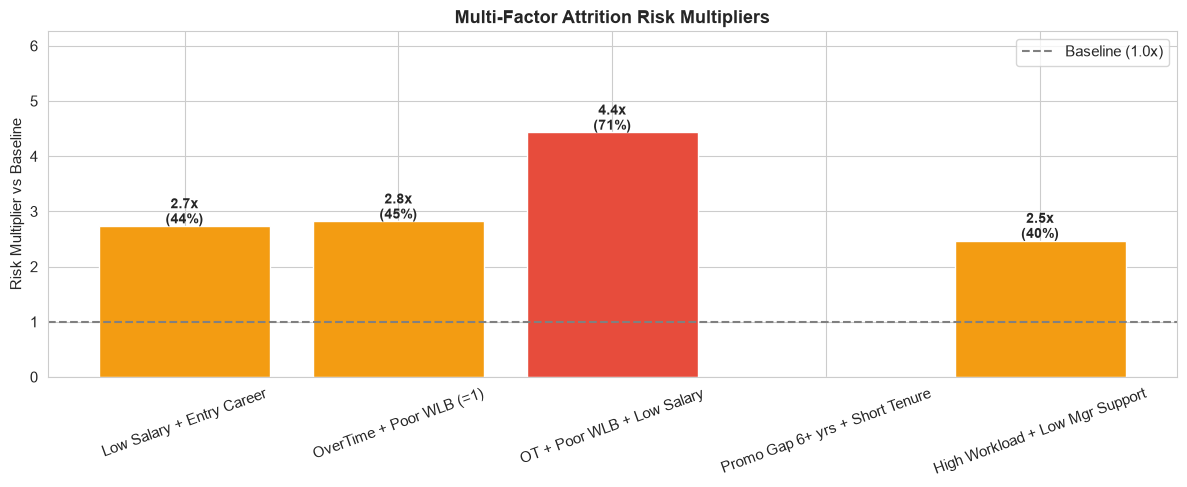

In [7]:
scenarios = [
    ('Low Salary + Entry Career',
     df[(df['SalaryBand']=='Low') & (df['ExperienceBand']=='Entry (0-2)')]['Attrition_Binary'].mean()),
    ('OverTime + Poor WLB (=1)',
     df[(df['OverTime']=='Yes') & (df['WorkLifeBalance']==1)]['Attrition_Binary'].mean()),
    ('OT + Poor WLB + Low Salary',
     df[(df['OverTime']=='Yes') & (df['WorkLifeBalance']==1) & (df['SalaryBand']=='Low')]['Attrition_Binary'].mean()),
    ('Promo Gap 6+ yrs + Short Tenure',
     df[(df['YearsSinceLastPromotion']>=6) & (df['TenureBand'].isin(['New (0-1)','Settling (2-3)']))]['Attrition_Binary'].mean()),
    ('High Workload + Low Mgr Support',
     df[(df['WorkloadScore']>=4) & (df['ManagerSupportScore']<=2)]['Attrition_Binary'].mean()),
]

base = df['Attrition_Binary'].mean()
print(f'Baseline attrition: {base*100:.1f}%')
print(f'{'Scenario':<40} {'Rate':>8} {'Multiplier':>10}')
print('-'*60)
for lbl, rate in scenarios:
    if not pd.isna(rate):
        print(f'{lbl:<40} {rate*100:>6.1f}%  {rate/base:>9.2f}x')

# Bar chart
fig, ax = plt.subplots(figsize=(12,5))
labels = [s[0] for s in scenarios]
rates  = [s[1] for s in scenarios]
mults  = [r/base if not pd.isna(r) else 0 for r in rates]
cols   = [RED if m>=3 else AMBER if m>=2 else TEAL for m in mults]

bars = ax.bar(labels, mults, color=cols, edgecolor='white')
ax.axhline(1.0, color='gray', linestyle='--', lw=1.5, label='Baseline (1.0x)')
for bar, m, r in zip(bars, mults, rates):
    if m>0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{m:.1f}x\n({r*100:.0f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Risk Multiplier vs Baseline')
ax.set_title('Multi-Factor Attrition Risk Multipliers', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.legend(); ax.set_ylim(0, max(mults)*1.3+0.5)
plt.tight_layout()
plt.show()